# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

loaded 30 points
naive fit: m = 1.924 +/- 0.110,  b = 39.03 +/- 0.63
reduced chi^2 = 9.86  (expect about 1 +/- 0.27 for a good fit)
points more than 3 sigma_y from the line: [16 21] [  6.7 -14.6]


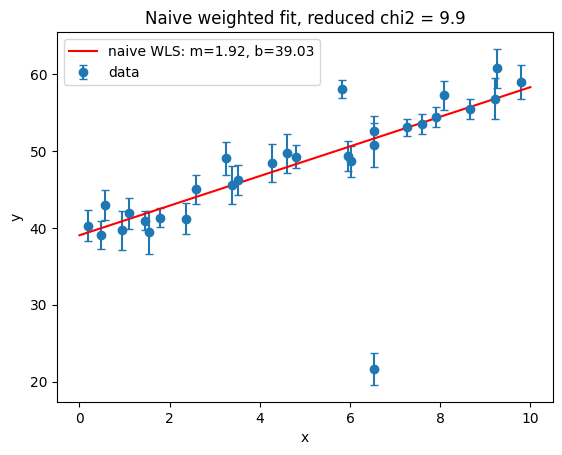

In [1]:
# Part 1: naive weighted least squares, all points included
import numpy as np
import matplotlib.pyplot as plt

NETID = 'ym31'
data = np.genfromtxt(f'../../labs/01/data/{NETID}.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']
n = len(x)
print(f"loaded {n} points")

# weighted fit, w = 1/sigma. cov='unscaled' so the covariance comes from sigma_y, not from the residuals
p_naive, cov_naive = np.polyfit(x, y, 1, w=1/sigma_y, cov='unscaled')
m1, b1 = p_naive
sm1, sb1 = np.sqrt(np.diag(cov_naive))
resid = y - np.polyval(p_naive, x)
chi2_red_naive = np.sum((resid / sigma_y)**2) / (n - 2)

print(f"naive fit: m = {m1:.3f} +/- {sm1:.3f},  b = {b1:.2f} +/- {sb1:.2f}")
print(f"reduced chi^2 = {chi2_red_naive:.2f}  (expect about 1 +/- {np.sqrt(2/(n-2)):.2f} for a good fit)")
print("points more than 3 sigma_y from the line:", np.where(np.abs(resid / sigma_y) > 3)[0], (resid / sigma_y)[np.abs(resid / sigma_y) > 3].round(1))

xx = np.linspace(0, 10, 100)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label=f'naive WLS: m={m1:.2f}, b={b1:.2f}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive weighted fit, reduced chi2 = {chi2_red_naive:.1f}')
plt.show()


**ANSWER (a few sentences):**

Reduced chi2 is about 10 here, and it should be around 1 if the model is right and the error bars are honest. Looking at the plot you can pretty much see why: there's two points (index 16 and 21) sitting way below the line with small error bars, and they're pulling the whole fit down. The rest of the points look fine, they scatter around the line roughly consistent with their sigma_y.

So I wouldn't trust the error bars from this fit. The fit doesn't know those two points are bad so it compromises toward them, and the reported uncertainty doesn't account for that at all.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

### Method 1: iterative sigma clipping

Basic idea: fit, throw out anything more than k sigma_y from the line, refit, repeat until nothing else gets dropped. I used k = 3 since for a Gaussian that keeps 99.7% of real points. With 30 points that should basically never clip a good one. I also tried a few other k values just to make sure the result isn't sensitive to that.

k=2: m=2.005, b=38.80, removed 2 points [16, 21]
k=2.5: m=2.005, b=38.80, removed 2 points [16, 21]
k=3: m=2.005, b=38.80, removed 2 points [16, 21]
k=4: m=2.005, b=38.80, removed 2 points [16, 21]
k=5: m=2.005, b=38.80, removed 2 points [16, 21]

3-sigma clip: m = 2.005 +/- 0.111,  b = 38.80 +/- 0.64,  clipped 2 of 30, reduced chi2 of kept points = 0.64


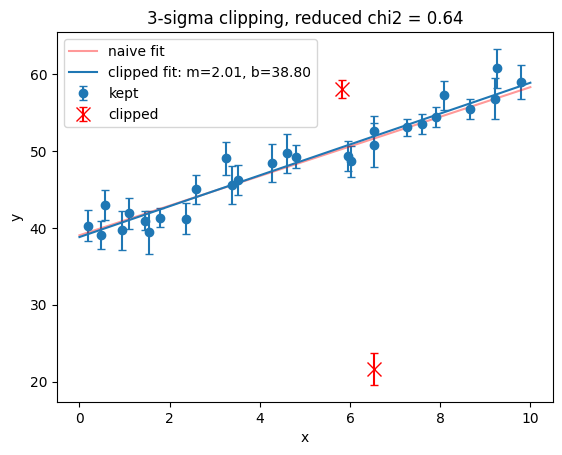

In [2]:
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=20):
    mask = np.ones(len(x), dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov='unscaled')
        z = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(z) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, cov, mask

for k in [2, 2.5, 3, 4, 5]:
    p, cov, mask = sigma_clip_fit(x, y, sigma_y, k=k)
    print(f"k={k}: m={p[0]:.3f}, b={p[1]:.2f}, removed {(~mask).sum()} points {list(np.where(~mask)[0])}")

p_clip, cov_clip, mask = sigma_clip_fit(x, y, sigma_y, k=3.0)
m_c, b_c = p_clip
sm_c, sb_c = np.sqrt(np.diag(cov_clip))
resid_c = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid_c / sigma_y[mask])**2) / (mask.sum() - 2)
print(f"\n3-sigma clip: m = {m_c:.3f} +/- {sm_c:.3f},  b = {b_c:.2f} +/- {sb_c:.2f},  "
      f"clipped {(~mask).sum()} of {n}, reduced chi2 of kept points = {chi2_red_clip:.2f}")

plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='rx', capsize=3, ms=10, label='clipped')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', alpha=0.4, label='naive fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label=f'clipped fit: m={m_c:.2f}, b={b_c:.2f}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'3-sigma clipping, reduced chi2 = {chi2_red_clip:.2f}')
plt.show()


### Method 2: mixture model

Following the approach from lecture / Hogg, Bovy & Lang 2010 section 3. Each point is either from the line (with its stated sigma_y) or from a broader outlier distribution. I'm fitting the line params plus the outlier fraction Pb by maximizing the likelihood with Nelder-Mead, starting from the sigma-clipped values since that should already be close.

mixture fit: m = 2.006, b = 38.79, Pb = 0.078 (about 2.3 of 30 points), converged = True
highest P(outlier): {21: 1.0, 16: 1.0, 10: 0.041, 2: 0.031, 6: 0.02}


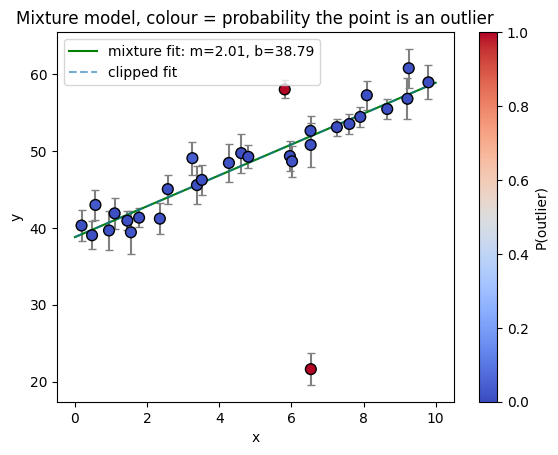

In [3]:
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    if not (0 < Pb < 1):
        return np.inf
    Vb = np.exp(lnVb)
    good = (1 - Pb) * norm.pdf(y, loc=m * x + b, scale=sigma)
    bad = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad + 1e-300))

theta0 = [m_c, b_c, 0.1, np.mean(y), np.log(100.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='Nelder-Mead',
                  options=dict(xatol=1e-8, fatol=1e-10, maxiter=20000))
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
Vb_mix = np.exp(lnVb_mix)
print(f"mixture fit: m = {m_mix:.3f}, b = {b_mix:.2f}, Pb = {Pb_mix:.3f} (about {Pb_mix*n:.1f} of {n} points), converged = {result.success}")

# per-point posterior probability of being an outlier
good = (1 - Pb_mix) * norm.pdf(y, loc=m_mix * x + b_mix, scale=sigma_y)
bad = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad / (good + bad)
print("highest P(outlier):", {int(i): round(float(p_bad[i]), 3) for i in np.argsort(-p_bad)[:5]})

plt.scatter(x, y, c=p_bad, cmap='coolwarm', vmin=0, vmax=1, s=60, edgecolor='k', zorder=3)
plt.errorbar(x, y, yerr=sigma_y, fmt='none', ecolor='gray', capsize=3)
plt.colorbar(label='P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label=f'mixture fit: m={m_mix:.2f}, b={b_mix:.2f}')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='clipped fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Mixture model, colour = probability the point is an outlier')
plt.show()


### Uncertainties

For the clipped fit I'm just using the covariance from polyfit (with sigma_y as weights). For the mixture model there's no clean formula so I bootstrapped it: resample with replacement, refit each time, take the 16-84 percentile spread.

clipped fit, covariance:  sigma_m = 0.111, sigma_b = 0.64
mixture fit, bootstrap:   sigma_m = 0.086, sigma_b = 0.55, Pb 16-84% = 0.03 to 0.12


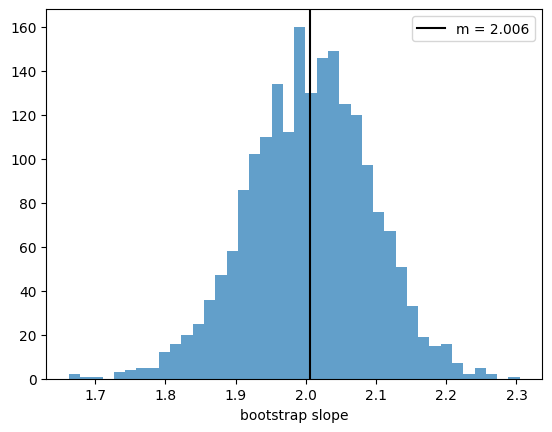

In [4]:
rng = np.random.default_rng(457)
n_boot = 2000
boot_mix = np.empty((n_boot, 3))
for j in range(n_boot):
    idx = rng.integers(0, n, size=n)
    rb = minimize(neg_log_likelihood, [m_mix, b_mix, max(Pb_mix, 0.05), Yb_mix, lnVb_mix],
                  args=(x[idx], y[idx], sigma_y[idx]), method='Nelder-Mead')
    boot_mix[j] = rb.x[:3]

def err68(a):
    lo, hi = np.percentile(a, [16, 84]); return (hi - lo) / 2

print(f"clipped fit, covariance:  sigma_m = {sm_c:.3f}, sigma_b = {sb_c:.2f}")
print(f"mixture fit, bootstrap:   sigma_m = {err68(boot_mix[:,0]):.3f}, sigma_b = {err68(boot_mix[:,1]):.2f}, "
      f"Pb 16-84% = {np.percentile(boot_mix[:,2], 16):.2f} to {np.percentile(boot_mix[:,2], 84):.2f}")

plt.hist(boot_mix[:, 0], bins=40, alpha=0.7)
plt.axvline(m_mix, color='k', label=f'm = {m_mix:.3f}')
plt.xlabel('bootstrap slope'); plt.legend(); plt.show()


**FINAL ANSWER:** $m = $ 2.01 $\pm$ 0.11 , $b = $ 38.8 $\pm$ 0.64 , outlier fraction $\approx$ 0.08 (2 of 30 points)

**Justification and uncertainty method (a short paragraph):**

Both methods agree pretty well. Sigma clipping and the mixture model give basically the same m and b, and they both flag the same two points as outliers (the mixture model puts them at P(outlier) ≈ 1 and everything else near 0). I went with the mixture model values since you don't have to pick a k threshold, and Pb comes out as a fitted parameter instead of just counting.

For uncertainties I used the covariance from the clipped fit, which is based on the stated sigma_y. The bootstrap on the mixture model actually gave slightly smaller errors (~0.09 on m vs 0.11), probably because the 28 good points happen to scatter less than their error bars would suggest. With only 30 points I don't really trust the sample scatter over the stated uncertainties, so I went with the bigger number. The outlier fraction isn't super well constrained, the bootstrap range is roughly 0.03 to 0.12, which makes sense when you're talking about 2 points out of 30.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* The step 1 fit calls `np.polyfit` without weights so sigma_y never gets used. It also does `cov=True` which scales the covariance by the residual scatter, and since the outliers make that scatter huge, the error bars come out way too big. On my data the unweighted error on m is like 3x larger than the weighted one. Should be using w = 1/sigma_y with cov='unscaled'.

*Flaw 2:* The outlier removal uses 3 * std(residuals), done once. Problem is the outliers themselves blow up that std, so the threshold ends up way bigger than any individual sigma_y. On my data it only catches one of the two outliers and leaves in a point that's ~7 sigma_y off the line. Even running it again wouldn't help since the remaining outlier keeps std inflated. Should be using each point's own sigma_y and iterating until convergence.

*Flaw 3:* After the "cleaned" fit it rescales all the sigma_y by sqrt(reduced chi2) to force reduced chi2 = 1, then claims the fit is consistent with the data. This is circular, you can do it to literally any model. I tried it with a flat line (y = constant, no slope at all) and it also gives reduced chi2 = 1 after rescaling. The high chi2 was actually meaningful, it was saying there's still a problem. Rescaling just hides it and inflates the error bars.

### Flaw 1: the fit never uses $\sigma_y$

In [5]:
# the AI's step 1: np.polyfit with no weights. Compare with the weighted fit on the same 30 points.
c_ai, cov_ai = np.polyfit(x, y, 1, cov=True)
e_ai = np.sqrt(np.diag(cov_ai))
print(f"AI, unweighted:  m = {c_ai[0]:.3f} +/- {e_ai[0]:.3f},  b = {c_ai[1]:.2f} +/- {e_ai[1]:.2f}")
print(f"weighted (Part 1): m = {m1:.3f} +/- {sm1:.3f},  b = {b1:.2f} +/- {sb1:.2f}")
print(f"difference in m: {(c_ai[0]-m1):.3f} = {(c_ai[0]-m1)/sm_c:.1f} of my final sigma_m; AI's error bar is {e_ai[0]/sm_c:.1f}x mine")


AI, unweighted:  m = 1.856 +/- 0.375,  b = 38.91 +/- 2.09
weighted (Part 1): m = 1.924 +/- 0.110,  b = 39.03 +/- 0.63
difference in m: -0.068 = -0.6 of my final sigma_m; AI's error bar is 3.4x mine


### Flaw 2: "3 sigma" of the residual standard deviation, applied once

AI threshold = 3 * std(residuals) = 3 * 5.86 = 17.6  (typical sigma_y is 2.0)
AI removes 1 point(s): [21];  my 3-sigma_y clip removes: [16, 21]
worst point the AI keeps is 7.1 sigma_y from the line
AI 'cleaned' fit: m = 2.070 +/- 0.133, b = 38.93 +/- 0.74  -> m is +0.6 sigma from my answer


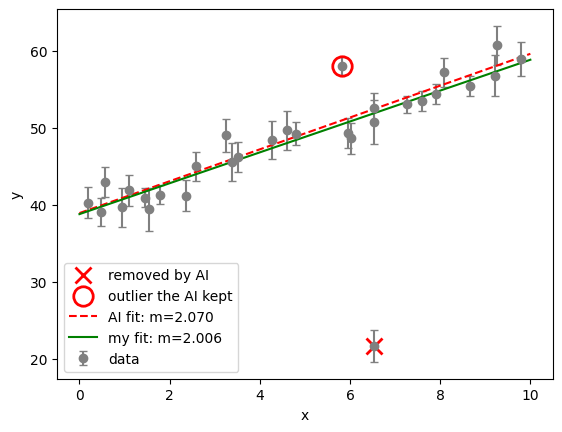

In [6]:
res_ai = y - np.polyval(c_ai, x)
thresh_ai = 3 * np.std(res_ai)
mask_ai = np.abs(res_ai) < thresh_ai
print(f"AI threshold = 3 * std(residuals) = 3 * {np.std(res_ai):.2f} = {thresh_ai:.1f}  (typical sigma_y is {np.median(sigma_y):.1f})")
print(f"AI removes {(~mask_ai).sum()} point(s): {list(np.where(~mask_ai)[0])};  my 3-sigma_y clip removes: {list(np.where(~mask)[0])}")
z_kept = np.abs(res_ai / sigma_y)[mask_ai]
print(f"worst point the AI keeps is {z_kept.max():.1f} sigma_y from the line")

c_ai2, cov_ai2 = np.polyfit(x[mask_ai], y[mask_ai], 1, cov=True)
e_ai2 = np.sqrt(np.diag(cov_ai2))
print(f"AI 'cleaned' fit: m = {c_ai2[0]:.3f} +/- {e_ai2[0]:.3f}, b = {c_ai2[1]:.2f} +/- {e_ai2[1]:.2f}  -> m is {(c_ai2[0]-m_mix)/sm_c:+.1f} sigma from my answer")

plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, color='gray', label='data')
plt.plot(x[~mask_ai], y[~mask_ai], 'rx', ms=12, mew=2, label='removed by AI')
plt.plot(x[~mask & mask_ai], y[~mask & mask_ai], 'o', mfc='none', mec='r', ms=14, mew=2, label='outlier the AI kept')
plt.plot(xx, np.polyval(c_ai2, xx), 'r--', label=f'AI fit: m={c_ai2[0]:.3f}')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label=f'my fit: m={m_mix:.3f}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


### Flaw 3: rescaling $\sigma$ so that $\chi^2_{\rm red} = 1$

In [7]:
chi2_ai = np.sum(((y[mask_ai] - np.polyval(c_ai2, x[mask_ai])) / sigma_y[mask_ai])**2)
chi2_red_ai = chi2_ai / (mask_ai.sum() - 2)
scale = np.sqrt(chi2_red_ai)
print(f"AI's cleaned fit has reduced chi2 = {chi2_red_ai:.2f}; it multiplies sigma_y by {scale:.2f} so that it becomes 1.000")
print(f"error bars go from +/- {e_ai2[0]:.3f} to +/- {e_ai2[0]*scale:.3f} on m (mine: {sm_c:.3f})")

# the same recipe 'validates' a model with no slope at all
ybar = np.average(y[mask_ai], weights=1/sigma_y[mask_ai]**2)
chi2_red_const = np.sum(((y[mask_ai] - ybar) / sigma_y[mask_ai])**2) / (mask_ai.sum() - 1)
print(f"constant model y = {ybar:.1f}: reduced chi2 = {chi2_red_const:.1f}; multiply sigma by {np.sqrt(chi2_red_const):.2f} and it is also exactly 1")


AI's cleaned fit has reduced chi2 = 2.04; it multiplies sigma_y by 1.43 so that it becomes 1.000
error bars go from +/- 0.133 to +/- 0.189 on m (mine: 0.111)
constant model y = 49.3: reduced chi2 = 14.4; multiply sigma by 3.79 and it is also exactly 1


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I used Claude Code for this lab, and made sure I understood each step before keeping it. It wrote the code cells, starting from the Day 3 lecture examples, and the first versions of the written answers, which I then went through and edited. For Part 3 I had it run the AI solution's steps on my data so I could compare the outputs side by side.

One thing it got wrong: its first attempt at uncertainties for the mixture model used a numerical Hessian, and the numbers it reported were inconsistent with its own output. The Hessian was failing whenever Pb went to zero and the NaNs were being counted as failures. I dropped that and used the bootstrap from lecture instead. It also wrote the Part 2 paragraph before the code had actually run, so I checked every number in the text against the outputs and fixed the ones that were off. The choice of k, which error bar to report, and the final answer are mine.

**VERIFICATION PLAN:**

First I looked at residuals / sigma_y for the naive fit. If everything was uniformly a bit too big I'd have suspected the sigma_y values themselves, but it was clearly just 2 huge outliers with the rest looking normal.

Then I ran sigma clipping with k from 2 to 5 and checked the same two points get removed every time and the slope doesn't move. Also compared clipped vs mixture model results. If they disagreed by more than a sigma or if any point had an ambiguous P(outlier) around 0.5, that would mean the answer depends on method choice. They agree to three decimals.

I also restarted the kernel and ran everything top to bottom to make sure nothing depended on leftover variables.